Initial Data Cleaning:

In [7]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [8]:
years = ["15", "16", "17", "18", "19", "21", "22", "23", "24"]
input_dir = r"C:\Users\nseel\CS\DATA1030\DATA-1030-Final-Project\Raw Data"
output_dir = r"C:\Users\nseel\CS\DATA1030\DATA-1030-Final-Project\Cleaned Data"
os.makedirs(output_dir, exist_ok=True)

cols_to_keep = [
    "SchYear", "DistName", "StudentGroup", "StudentGroup_TotalTested",
    "StudentSubGroup", "StudentSubGroup_TotalTested", "ProficientOrAbove_count",
    "ProficientOrAbove_percent", "ParticipationRate", "DistLocale"
]

for i in years:
    input_path = os.path.join(input_dir, f"edc-2.1-california-20{i}.csv")
    print("Importing 20" + i + " data")
    df = pd.read_csv(input_path, low_memory=False)  # Suppress DtypeWarning
    df = df[df["DataLevel"] == "District"]
    df = df[df["Subject"] == "math"]
    df = df[df["GradeLevel"] == "G04"]
    year = int("20" + i)
    df["SchYear"] = year
    df = df[cols_to_keep]
    df["ProficientOrAbove_count"] = pd.to_numeric(df["ProficientOrAbove_count"], errors="coerce")
    df["ProficientOrAbove_percent"] = pd.to_numeric(df["ProficientOrAbove_percent"], errors="coerce")
    df["ParticipationRate"] = pd.to_numeric(df["ParticipationRate"], errors="coerce")
    output_path = os.path.join(output_dir, f"ca20{i}.csv")
    df.to_csv(output_path, index=False)

all_files = glob.glob(os.path.join(output_dir, "ca20*.csv"))
ca_all = pd.concat((pd.read_csv(f, low_memory=False) for f in all_files), ignore_index=True)
ca_all.to_csv(os.path.join(output_dir, "ca_all_years.csv"), index=False)

Importing 2015 data
Importing 2016 data
Importing 2017 data
Importing 2018 data
Importing 2019 data
Importing 2021 data
Importing 2022 data
Importing 2023 data
Importing 2024 data


ProficientOrAbove_count        33.63
ProficientOrAbove_percent      33.63
StudentSubGroup_TotalTested    18.20
ParticipationRate              18.20
DistName                        0.00
SchYear                         0.00
StudentSubGroup                 0.00
StudentGroup_TotalTested        0.00
StudentGroup                    0.00
DistLocale                      0.00
dtype: float64
count    1268.00
mean        0.37
std         0.18
min         0.00
25%         0.24
50%         0.34
75%         0.48
max         0.95
Name: ProficientOrAbove_percent, dtype: float64


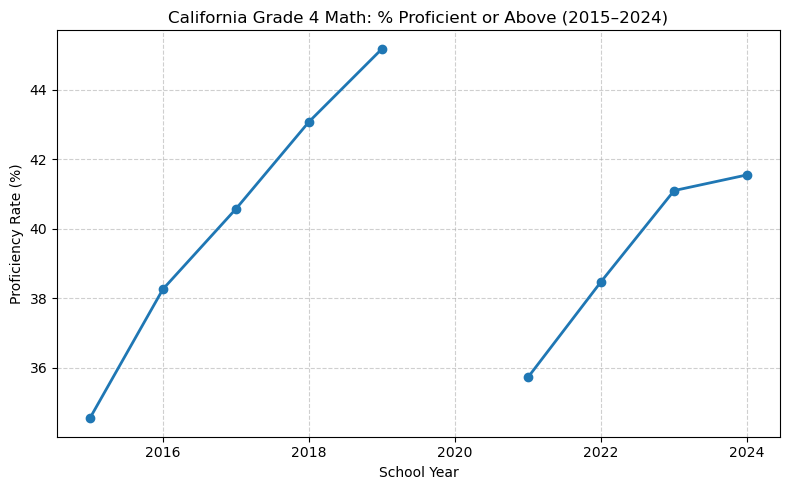

Saved: aggregate_trend.png


C:\Users\nseel\AppData\Local\Temp\ipykernel_30944\1744582470.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years, patch_artist=True)


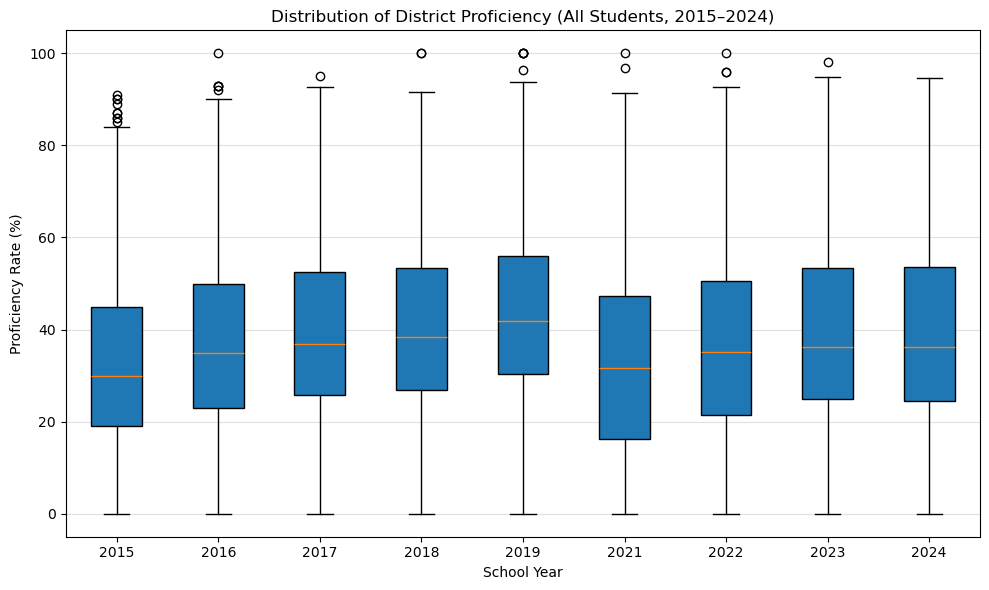

Saved: district_boxplot.png


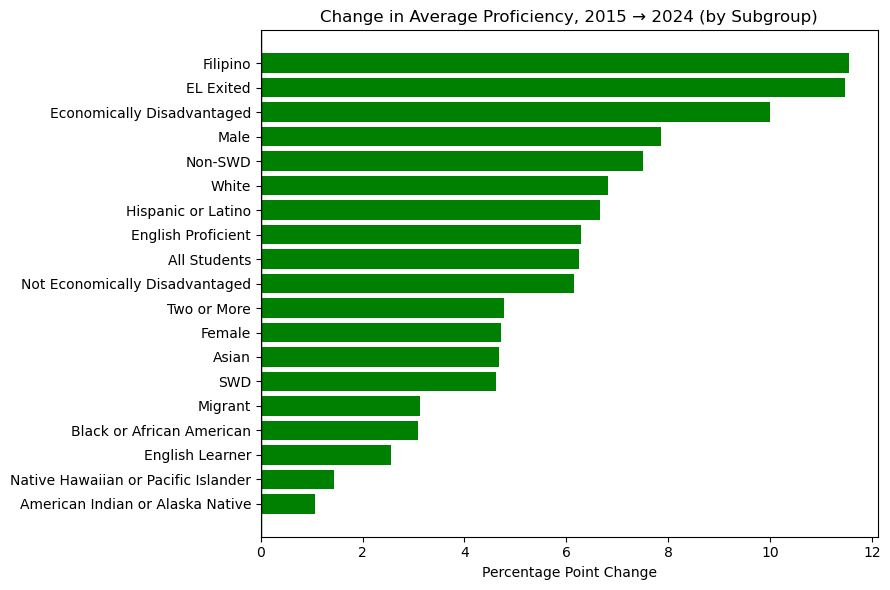

Saved: subgroup_change_2015_2024.png


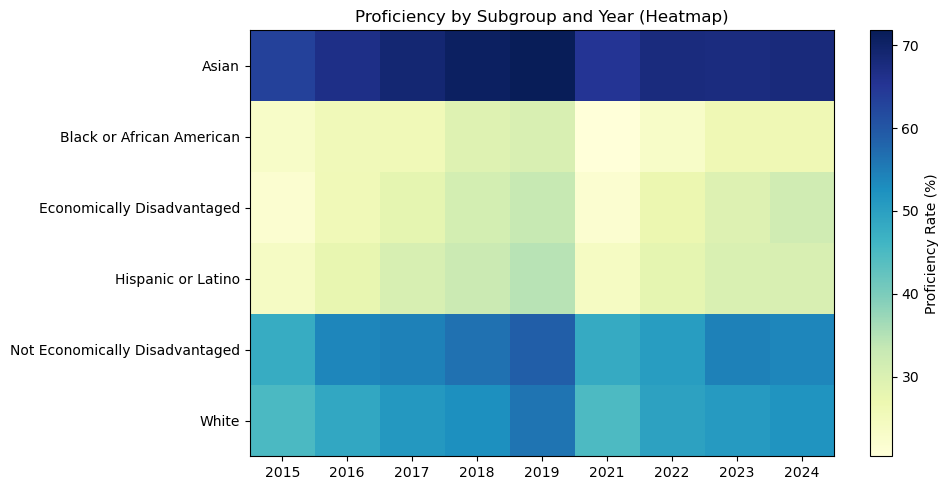

Saved: heatmap_subgroup.png


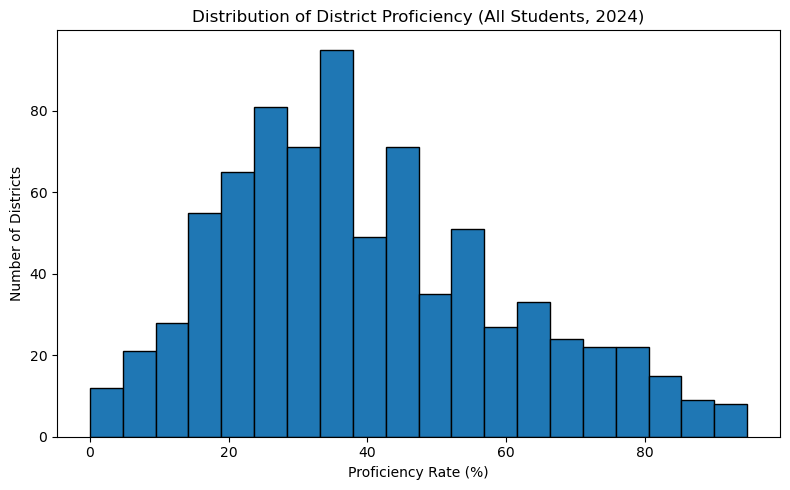

Saved: histogram_districts_2024.png


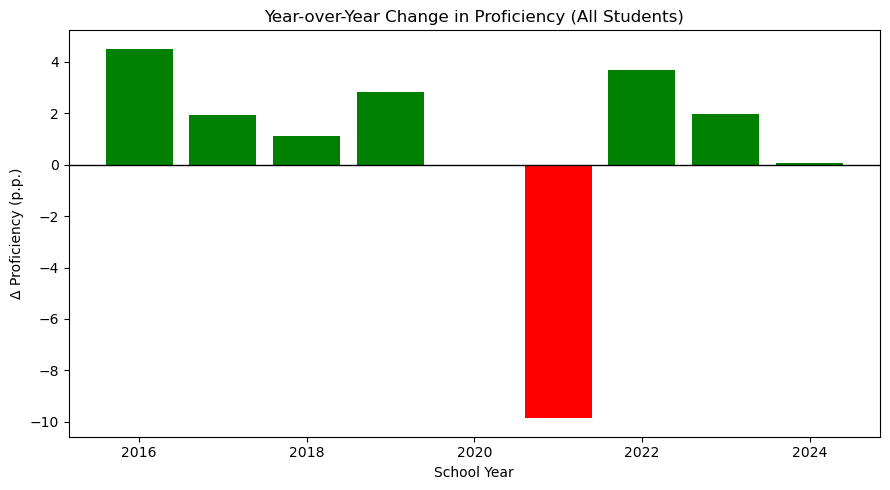

Saved: yoy_change.png


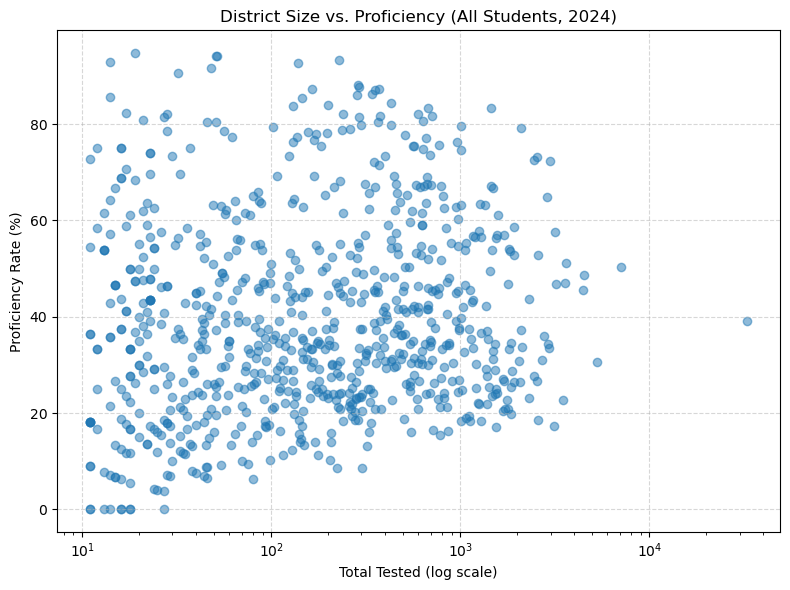

Saved: district_size_vs_proficiency.png


In [16]:
df = pd.read_csv(r"C:\Users\nseel\CS\DATA1030\DATA-1030-Final-Project\Cleaned Data\ca_all_years.csv")

save_dir = r"C:\Users\nseel\CS\DATA1030\Final Project\Visualizations"
os.makedirs(save_dir, exist_ok=True)

# Coerce numerics
for col in ["ProficientOrAbove_count", "StudentSubGroup_TotalTested",
            "ProficientOrAbove_percent", "ParticipationRate"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Helper: insert NaNs for missing years (like 2020)
def with_year_gaps(years, values):
    x, y = [], []
    for i in range(len(years)):
        x.append(years[i]); y.append(values[i])
        if i < len(years)-1 and (years[i+1] - years[i] > 1):
            x.append(years[i]+1); y.append(np.nan)
    return x, y

# Missing Values
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.round(2))

# Summary Stats
if "DistName" in df.columns:
    district_summary = (
        df.groupby("DistName")["ProficientOrAbove_percent"]
          .mean()
          .describe()
          .round(2)
    )
    print(district_summary)


# ================================================================
# Aggregate Proficiency Over Time (Main Line Graph)
# ================================================================
all_df = df[df["StudentSubGroup"] == "All Students"]
agg_all = (all_df.groupby("SchYear")
            .agg(Proficient=("ProficientOrAbove_count", "sum"),
                 Tested=("StudentSubGroup_TotalTested", "sum"))
            .reset_index())
agg_all["Rate"] = 100 * agg_all["Proficient"] / agg_all["Tested"]

years, rates = agg_all["SchYear"].to_numpy(), agg_all["Rate"].to_numpy()
x, y = with_year_gaps(years, rates)

plt.figure(figsize=(8,5))
plt.plot(x, y, marker="o", linewidth=2)
plt.title("California Grade 4 Math: % Proficient or Above (2015–2024)")
plt.xlabel("School Year"); plt.ylabel("Proficiency Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "aggregate_trend.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: aggregate_trend.png")

# ================================================================
# Boxplot of District Proficiency by Year
# ================================================================
plt.figure(figsize=(10,6))
box = df[(df["StudentSubGroup"]=="All Students") & df["ProficientOrAbove_percent"].notna()]
years = sorted(box["SchYear"].unique())
data = [ (box.loc[box["SchYear"]==y, "ProficientOrAbove_percent"]*100).values for y in years ]
plt.boxplot(data, labels=years, patch_artist=True)
plt.title("Distribution of District Proficiency (All Students, 2015–2024)")
plt.xlabel("School Year"); plt.ylabel("Proficiency Rate (%)")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "district_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: district_boxplot.png")

# ================================================================
# Change from 2015 → 2024 (by Subgroup)
# ================================================================
base = df[df["SchYear"].isin([2015,2024])]
agg_change = (base.groupby(["SchYear","StudentSubGroup"])
                   .agg(Rate=("ProficientOrAbove_percent","mean"))
                   .reset_index())
pivot = agg_change.pivot(index="StudentSubGroup", columns="SchYear", values="Rate").dropna()
pivot["Change"] = (pivot[2024] - pivot[2015]) * 100
pivot = pivot.sort_values("Change")

plt.figure(figsize=(9,6))
plt.barh(pivot.index, pivot["Change"], color=np.where(pivot["Change"]>0,"green","red"))
plt.title("Change in Average Proficiency, 2015 → 2024 (by Subgroup)")
plt.xlabel("Percentage Point Change")
plt.axvline(0, color="black", lw=1)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "subgroup_change_2015_2024.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: subgroup_change_2015_2024.png")

# ================================================================
# Heatmap (Subgroup × Year)
# ================================================================
subset = ["Asian","Black or African American","Hispanic or Latino","White",
           "Economically Disadvantaged","Not Economically Disadvantaged"]
pivot = (df[df["StudentSubGroup"].isin(subset)]
         .groupby(["StudentSubGroup","SchYear"])["ProficientOrAbove_percent"]
         .mean().unstack())

plt.figure(figsize=(10,5))
plt.imshow(pivot*100, cmap="YlGnBu", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Proficiency Rate (%)")
plt.title("Proficiency by Subgroup and Year (Heatmap)")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "heatmap_subgroup.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: heatmap_subgroup.png")

# ================================================================
# Histogram of District Proficiency (2024)
# ================================================================
subset = df[(df["SchYear"]==2024) & (df["StudentSubGroup"]=="All Students")]
plt.figure(figsize=(8,5))
plt.hist(subset["ProficientOrAbove_percent"]*100, bins=20, edgecolor="black")
plt.title("Distribution of District Proficiency (All Students, 2024)")
plt.xlabel("Proficiency Rate (%)"); plt.ylabel("Number of Districts")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "histogram_districts_2024.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: histogram_districts_2024.png")

# ================================================================
# 7️⃣  Year-over-Year Change Bar Chart
# ================================================================
agg = (df[df["StudentSubGroup"]=="All Students"]
       .groupby("SchYear")["ProficientOrAbove_percent"].mean().reset_index())
agg["YoY_Change"] = agg["ProficientOrAbove_percent"].diff()*100

plt.figure(figsize=(9,5))
plt.bar(agg["SchYear"], agg["YoY_Change"], color=np.where(agg["YoY_Change"]>0,"green","red"))
plt.axhline(0, color="black", lw=1)
plt.title("Year-over-Year Change in Proficiency (All Students)")
plt.xlabel("School Year"); plt.ylabel("Δ Proficiency (p.p.)")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "yoy_change.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: yoy_change.png")

# ================================================================
# District Size vs. Proficiency (2024)
# ================================================================
latest = df[(df["SchYear"]==2024) & (df["StudentSubGroup"]=="All Students")]
plt.figure(figsize=(8,6))
plt.scatter(latest["StudentSubGroup_TotalTested"], latest["ProficientOrAbove_percent"]*100, alpha=0.5)
plt.xscale("log")
plt.title("District Size vs. Proficiency (All Students, 2024)")
plt.xlabel("Total Tested (log scale)"); plt.ylabel("Proficiency Rate (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "district_size_vs_proficiency.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: district_size_vs_proficiency.png")


In [17]:
df = pd.read_csv(r"C:\Users\nseel\CS\DATA1030\DATA-1030-Final-Project\Cleaned Data\ca_all_years.csv")
df.columns = df.columns.str.strip()
exclude_groups = [
    "Disability Status", "EL Status", "Migrant Status",
    "Homeless Enrolled Status", "Military Connected Status",
    "Foster Care Status"
]
df = df[~df["StudentGroup"].isin(exclude_groups)]
num_cols = [
    "ProficientOrAbove_percent",
    "ProficientOrAbove_count",
    "StudentGroup_TotalTested",
    "StudentSubGroup_TotalTested",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
pct_wide = df.pivot_table(
    index=["SchYear", "DistName", "DistLocale"],
    columns=["StudentGroup", "StudentSubGroup"],
    values="ProficientOrAbove_percent",
    aggfunc="mean"
)
count_wide = df.pivot_table(
    index=["SchYear", "DistName", "DistLocale"],
    columns=["StudentGroup", "StudentSubGroup"],
    values="ProficientOrAbove_count",
    aggfunc="sum"  
)
group_total_wide = df.pivot_table(
    index=["SchYear", "DistName", "DistLocale"],
    columns=["StudentGroup", "StudentSubGroup"],
    values="StudentGroup_TotalTested",
    aggfunc="sum"
)
subgroup_total_wide = df.pivot_table(
    index=["SchYear", "DistName", "DistLocale"],
    columns=["StudentGroup", "StudentSubGroup"],
    values="StudentSubGroup_TotalTested",
    aggfunc="sum"
)
pct_wide.columns = [f"{g}_{sg}_ProficientPct" for g, sg in pct_wide.columns]
count_wide.columns = [f"{g}_{sg}_ProficientCount" for g, sg in count_wide.columns]
group_total_wide.columns = [f"{g}_{sg}_GroupTotalTested" for g, sg in group_total_wide.columns]
subgroup_total_wide.columns = [f"{g}_{sg}_SubgroupTotalTested" for g, sg in subgroup_total_wide.columns]
df = (
    pd.concat([pct_wide, count_wide, group_total_wide, subgroup_total_wide], axis=1)
      .reset_index()
)
cols_to_remove = [
    'All Students_All Students_GroupTotalTested',
    'Economic Status_Economically Disadvantaged_GroupTotalTested',
    'Economic Status_Not Economically Disadvantaged_GroupTotalTested',
    'Gender_Female_GroupTotalTested',
    'Gender_Male_GroupTotalTested',
    'RaceEth_American Indian or Alaska Native_GroupTotalTested',
    'RaceEth_Asian_GroupTotalTested',
    'RaceEth_Black or African American_GroupTotalTested',
    'RaceEth_Filipino_GroupTotalTested',
    'RaceEth_Hispanic or Latino_GroupTotalTested',
    'RaceEth_Native Hawaiian or Pacific Islander_GroupTotalTested',
    'RaceEth_Two or More_GroupTotalTested',
    'RaceEth_White_GroupTotalTested'
]

df = df.drop(columns=cols_to_remove)

rename_dict = {
    'SchYear': 'Year',
    'DistName': 'District',
    'All Students_All Students_ProficientPct': 'Total_ProficientPct',
    'Economic Status_Economically Disadvantaged_ProficientPct': 'EconDisadv_ProficientPct',
    'Economic Status_Not Economically Disadvantaged_ProficientPct': 'NotEconDisadv_ProficientPct',
    'Gender_Female_ProficientPct': 'Female_ProficientPct',
    'Gender_Male_ProficientPct': 'Male_ProficientPct',
    'RaceEth_American Indian or Alaska Native_ProficientPct': 'AIAN_ProficientPct',
    'RaceEth_Asian_ProficientPct': 'Asian_ProficientPct',
    'RaceEth_Black or African American_ProficientPct': 'Black_ProficientPct',
    'RaceEth_Filipino_ProficientPct': 'Filipino_ProficientPct',
    'RaceEth_Hispanic or Latino_ProficientPct': 'Hisp_ProficientPct',
    'RaceEth_Native Hawaiian or Pacific Islander_ProficientPct': 'NHPI_ProficientPct',
    'RaceEth_Two or More_ProficientPct': 'TwoOrMore_ProficientPct',
    'RaceEth_White_ProficientPct': 'White_ProficientPct',

    'All Students_All Students_ProficientCount': 'Total_ProficientCount',
    'Economic Status_Economically Disadvantaged_ProficientCount': 'EconDisadv_ProficientCount',
    'Economic Status_Not Economically Disadvantaged_ProficientCount': 'NotEconDisadv_ProficientCount',
    'Gender_Female_ProficientCount': 'Female_ProficientCount',
    'Gender_Male_ProficientCount': 'Male_ProficientCount',
    'RaceEth_American Indian or Alaska Native_ProficientCount': 'AIAN_ProficientCount',
    'RaceEth_Asian_ProficientCount': 'Asian_ProficientCount',
    'RaceEth_Black or African American_ProficientCount': 'Black_ProficientCount',
    'RaceEth_Filipino_ProficientCount': 'Filipino_ProficientCount',
    'RaceEth_Hispanic or Latino_ProficientCount': 'Hisp_ProficientCount',
    'RaceEth_Native Hawaiian or Pacific Islander_ProficientCount': 'NHPI_ProficientCount',
    'RaceEth_Two or More_ProficientCount': 'TwoOrMore_ProficientCount',
    'RaceEth_White_ProficientCount': 'White_ProficientCount',

    'All Students_All Students_SubgroupTotalTested': 'Total_Count',
    'Economic Status_Economically Disadvantaged_SubgroupTotalTested': 'EconDisadv_Count',
    'Economic Status_Not Economically Disadvantaged_SubgroupTotalTested': 'NotEconDisadv_Count',
    'Gender_Female_SubgroupTotalTested': 'Female_Count',
    'Gender_Male_SubgroupTotalTested': 'Male_Count',
    'RaceEth_American Indian or Alaska Native_SubgroupTotalTested': 'AIAN_Count',
    'RaceEth_Asian_SubgroupTotalTested': 'Asian_Count',
    'RaceEth_Black or African American_SubgroupTotalTested': 'Black_Count',
    'RaceEth_Filipino_SubgroupTotalTested': 'Filipino_Count',
    'RaceEth_Hispanic or Latino_SubgroupTotalTested': 'Hisp_Count',
    'RaceEth_Native Hawaiian or Pacific Islander_SubgroupTotalTested': 'NHPI_Count',
    'RaceEth_Two or More_SubgroupTotalTested': 'TwoOrMore_Count',
    'RaceEth_White_SubgroupTotalTested': 'White_Count'
}
df.rename(columns=rename_dict, inplace=True)
df['District'] = df['District'].str.replace('School District', '', regex=False).str.strip()
df['District'] = df['District'].str.lower()
df = df.dropna(subset=['Total_ProficientPct'])
df = df[df['Year'] <= 2019]
df = df.drop_duplicates()
df = df.groupby("District").filter(lambda g: g["Year"].nunique() >= 5)


def add_missing_indicators(df, cols):
    for col in cols:
        df[col + "_missing"] = df[col].isna().astype(int)
    return df

pct_cols = [c for c in df.columns if c.endswith("ProficientPct")]
count_cols = [c for c in df.columns if c.endswith("Count")]

missing_cols = pct_cols + count_cols

df = add_missing_indicators(df, missing_cols)
df = df.sort_values(["District", "Year"])

for lag in range(1, 5):
    df[f"Total_ProficientPct_lag{lag}"] = (
        df.groupby("District")["Total_ProficientPct"].shift(lag)
    )

df.to_csv(
    r"C:\Users\nseel\CS\DATA1030\DATA-1030-Final-Project\Cleaned Data\ca_all_years_wide.csv",
    index=False
)







Shape: (3364, 85)

Columns:
 ['Year', 'District', 'DistLocale', 'Total_ProficientPct', 'EconDisadv_ProficientPct', 'NotEconDisadv_ProficientPct', 'Female_ProficientPct', 'Male_ProficientPct', 'AIAN_ProficientPct', 'Asian_ProficientPct', 'Black_ProficientPct', 'Filipino_ProficientPct', 'Hisp_ProficientPct', 'NHPI_ProficientPct', 'TwoOrMore_ProficientPct', 'White_ProficientPct', 'Total_ProficientCount', 'EconDisadv_ProficientCount', 'NotEconDisadv_ProficientCount', 'Female_ProficientCount', 'Male_ProficientCount', 'AIAN_ProficientCount', 'Asian_ProficientCount', 'Black_ProficientCount', 'Filipino_ProficientCount', 'Hisp_ProficientCount', 'NHPI_ProficientCount', 'TwoOrMore_ProficientCount', 'White_ProficientCount', 'Total_Count', 'EconDisadv_Count', 'NotEconDisadv_Count', 'Female_Count', 'Male_Count', 'AIAN_Count', 'Asian_Count', 'Black_Count', 'Filipino_Count', 'Hisp_Count', 'NHPI_Count', 'TwoOrMore_Count', 'White_Count', 'Total_ProficientPct_missing', 'EconDisadv_ProficientPct_missing',

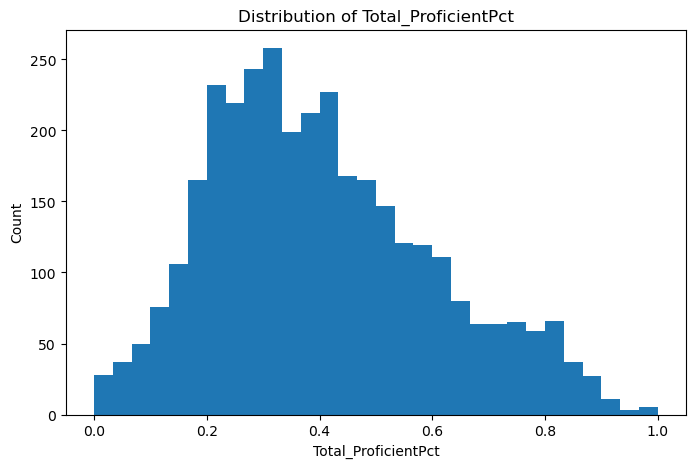

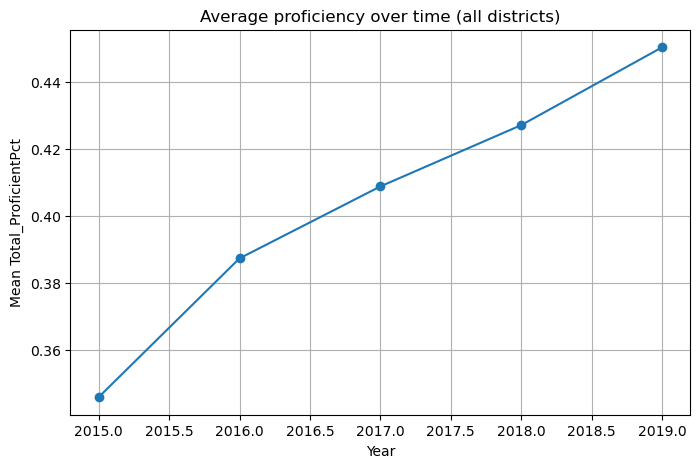

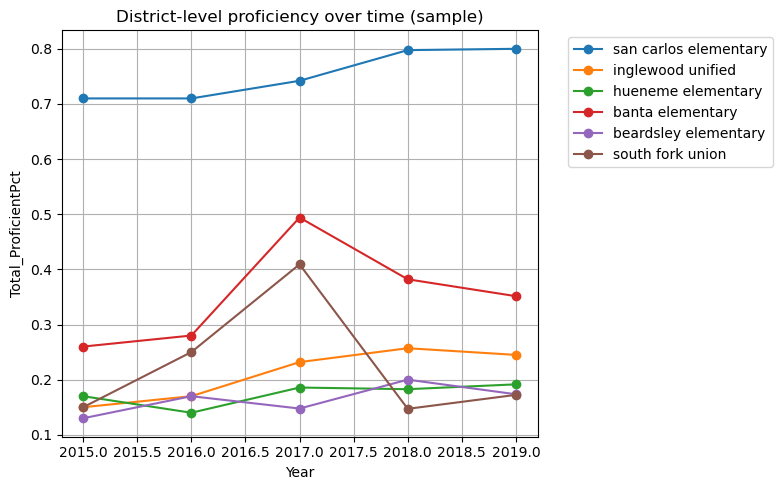

Total_ProficientPct         1.000000
Total_ProficientPct_lag2    0.871087
Total_ProficientPct_lag1    0.868218
Total_ProficientPct_lag4    0.841152
Total_ProficientPct_lag3    0.815967
Name: Total_ProficientPct, dtype: float64


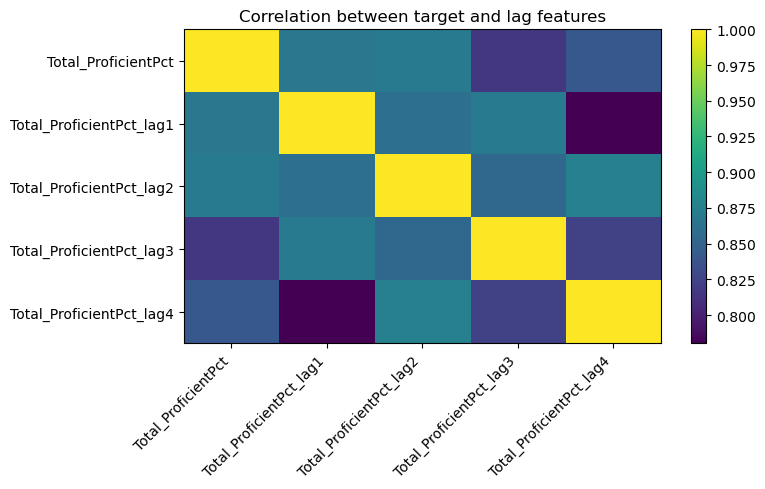

In [18]:
plt.rcParams["figure.figsize"] = (8, 5)

PATH = r"C:\Users\nseel\CS\DATA1030\DATA-1030-Final-Project\Cleaned Data\ca_all_years_wide.csv"

DISTRICT_COL = "District"              # change if different
YEAR_COL     = "Year"                  # change if different
TARGET_COL   = "Total_ProficientPct"   # change if different

df = pd.read_csv(PATH)
df.head()

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values per column:")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

print("\nMissing value % (top 15):")
print((missing / len(df) * 100).round(2).head(15))
print("\nYear range:", df[YEAR_COL].min(), "→", df[YEAR_COL].max())
print("Unique years:", sorted(df[YEAR_COL].unique()))

print("\n# of districts:", df[DISTRICT_COL].nunique())

years_per_dist = (
    df.groupby(DISTRICT_COL)[YEAR_COL]
      .nunique()
      .sort_values()
)

print("\nYears of data per district (describe):")
print(years_per_dist.describe())

print("\nExample of districts with few years:")
print(years_per_dist.head(15))
lag_cols = [c for c in df.columns if c.startswith(TARGET_COL + "_lag")]
print("Lag columns:", lag_cols)

print("\nMissingness in lag columns:")
print(df[lag_cols].isna().sum())

# rows where all lags are present and target is present
complete_rows = df[[TARGET_COL] + lag_cols].notna().all(axis=1)
print("\nRows with complete target + all lags:", complete_rows.sum(), "of", len(df))

# how many complete rows per district
complete_per_dist = complete_rows.groupby(df[DISTRICT_COL]).sum().sort_values()
print("\nComplete rows per district (with all lags):")
print(complete_per_dist.describe())
print(complete_per_dist.head(15))

df[TARGET_COL].describe()
plt.hist(df[TARGET_COL].dropna(), bins=30)
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.title("Distribution of " + TARGET_COL)
plt.show()
# Overall mean over time
mean_by_year = df.groupby(YEAR_COL)[TARGET_COL].mean()

mean_by_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Mean " + TARGET_COL)
plt.title("Average proficiency over time (all districts)")
plt.grid(True)
plt.show()
# Pick a few random districts and plot their time series
sample_dists = df[DISTRICT_COL].dropna().unique()
sample_dists = np.random.choice(sample_dists, size=min(6, len(sample_dists)), replace=False)

for d in sample_dists:
    sub = df[df[DISTRICT_COL] == d].sort_values(YEAR_COL)
    plt.plot(sub[YEAR_COL], sub[TARGET_COL], marker="o", label=d)

plt.xlabel("Year")
plt.ylabel(TARGET_COL)
plt.title("District-level proficiency over time (sample)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

cols_for_corr = [TARGET_COL] + lag_cols
corr = df[cols_for_corr].corr()
print(corr[TARGET_COL].sort_values(ascending=False))

# simple heatmap
fig, ax = plt.subplots()
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(cols_for_corr)))
ax.set_yticks(range(len(cols_for_corr)))
ax.set_xticklabels(cols_for_corr, rotation=45, ha="right")
ax.set_yticklabels(cols_for_corr)
plt.colorbar(im, ax=ax)
plt.title("Correlation between target and lag features")
plt.tight_layout()
plt.show()



DATA SPLITTING STRATEGY

Train set (2015-2017): 2019 observations (60.0%)
Validation set (2018): 673 observations (20.0%)
Test set (2019):       672 observations (20.0%)

Train: X shape = (2019, 83), y shape = (2019,)
Val:   X shape = (673, 83), y shape = (673,)
Test:  X shape = (672, 83), y shape = (672,)

MODEL TRAINING

Training XGBoost on 2015-2017 data...
Training complete!

MODEL PERFORMANCE - XGBOOST

Train (2015-2017):
  RMSE: 0.0031
  R²:   0.9998

Validation (2018):
  RMSE: 0.0192
  R²:   0.9904

Test (2019):
  RMSE: 0.0239
  R²:   0.9842

BASELINE MODEL - PERSISTENCE (t = t-1)

Validation (2018):
  RMSE: 0.1044
  R²:   0.7144

Test (2019):
  RMSE: 0.0998
  R²:   0.7234

FINAL COMPARISON - XGBOOST vs BASELINE

             Split  Baseline_RMSE  Baseline_R²  XGBoost_RMSE  XGBoost_R²  RMSE_Improvement_%
Validation (2018)       0.104400     0.714425      0.019161    0.990380           81.646352
      Test (2019)       0.099757     0.723365      0.023868    0.984164           76.

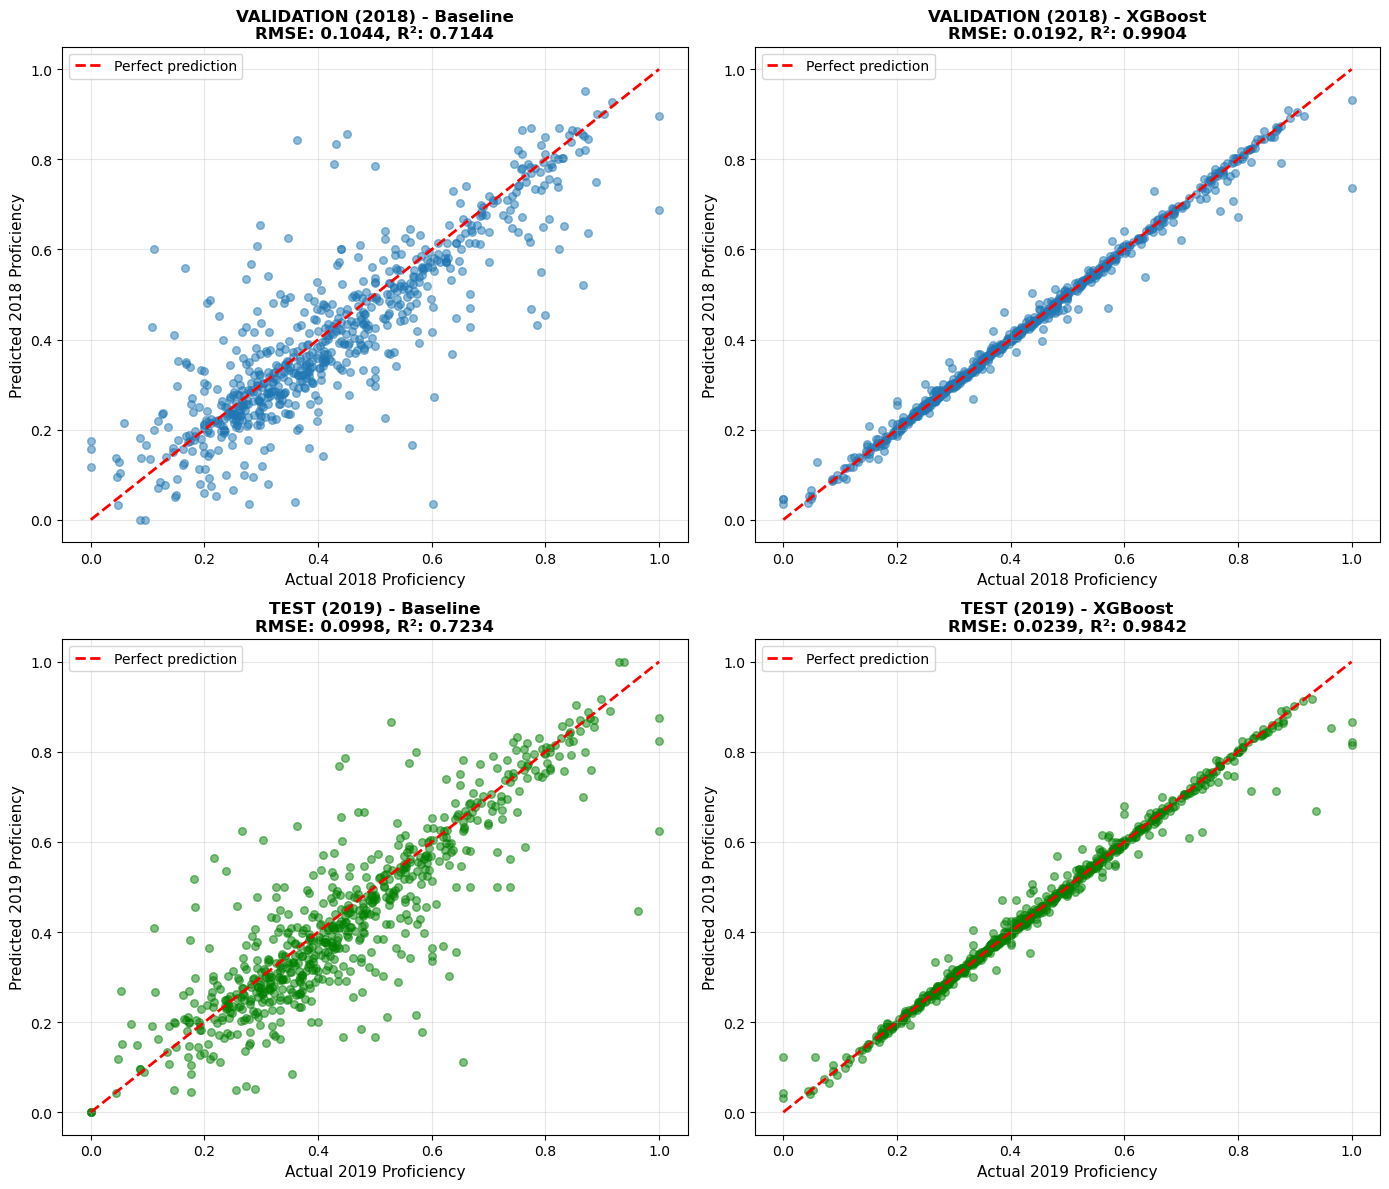


Plot saved as 'model_comparison_predictions.png'


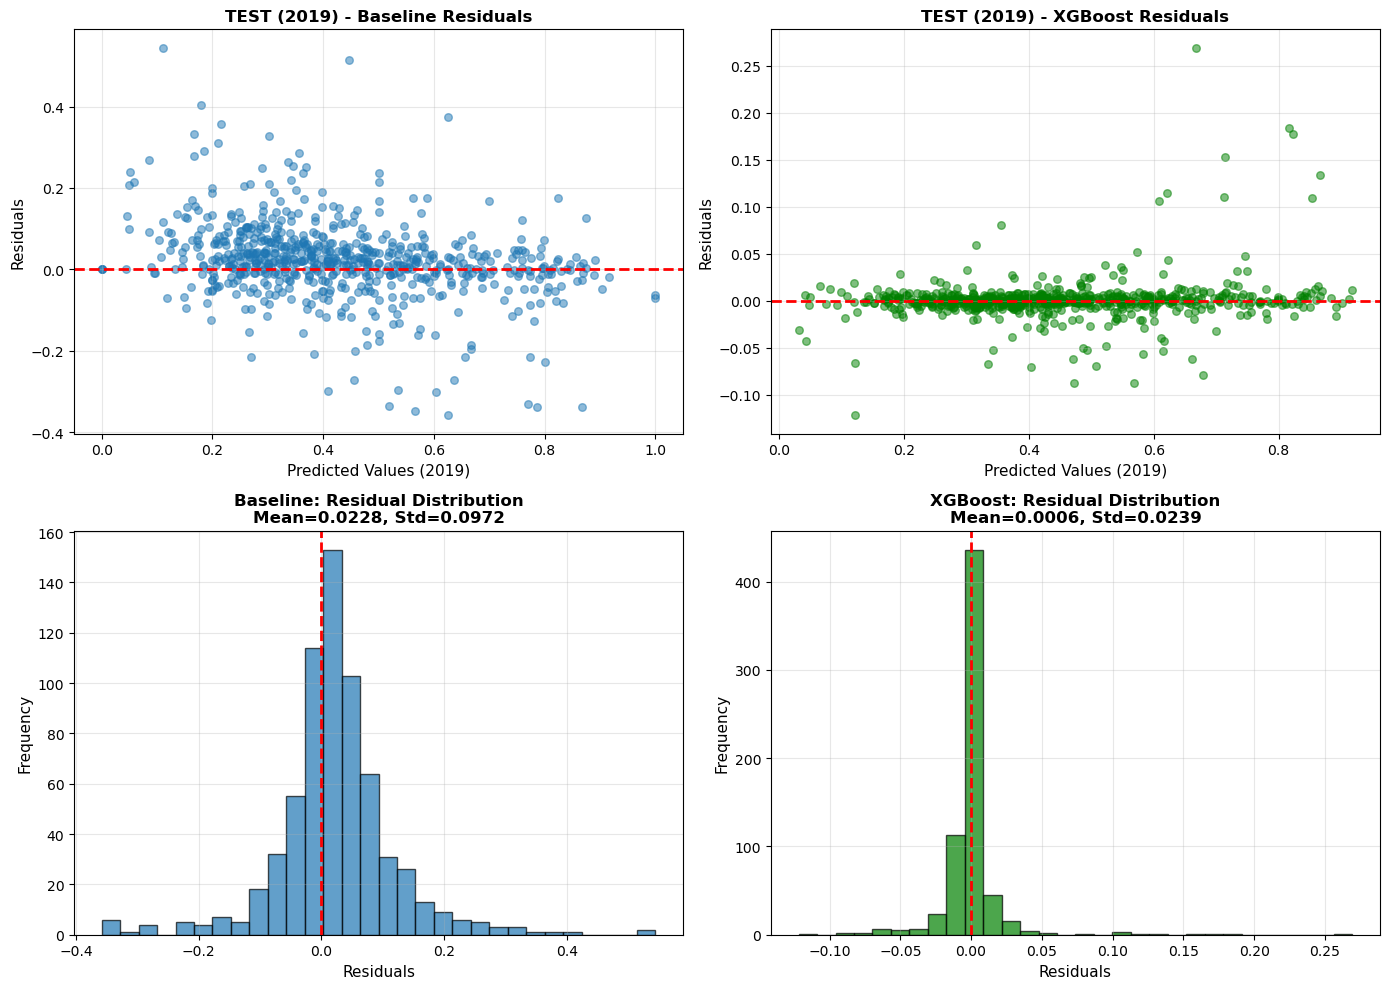

Plot saved as 'residual_analysis_test.png'

FEATURE IMPORTANCE (TOP 20)

                                Feature  Importance
         remainder__Male_ProficientPct    0.504539
       remainder__Female_ProficientPct    0.257293
        remainder__White_ProficientPct    0.050687
   remainder__EconDisadv_ProficientPct    0.042641
remainder__NotEconDisadv_ProficientPct    0.038923
      remainder__Total_ProficientCount    0.037348
           remainder__EconDisadv_Count    0.010138
   remainder__Total_ProficientPct_lag1    0.008998
                remainder__Total_Count    0.007824
 remainder__EconDisadv_ProficientCount    0.006058
         remainder__Hisp_ProficientPct    0.004760
    remainder__TwoOrMore_ProficientPct    0.004343
      remainder__White_ProficientCount    0.002563
         cat__DistLocale_Rural, remote    0.001721
 remainder__Male_ProficientPct_missing    0.001446
        remainder__Asian_ProficientPct    0.001425
   remainder__Total_ProficientPct_lag2    0.001423
        

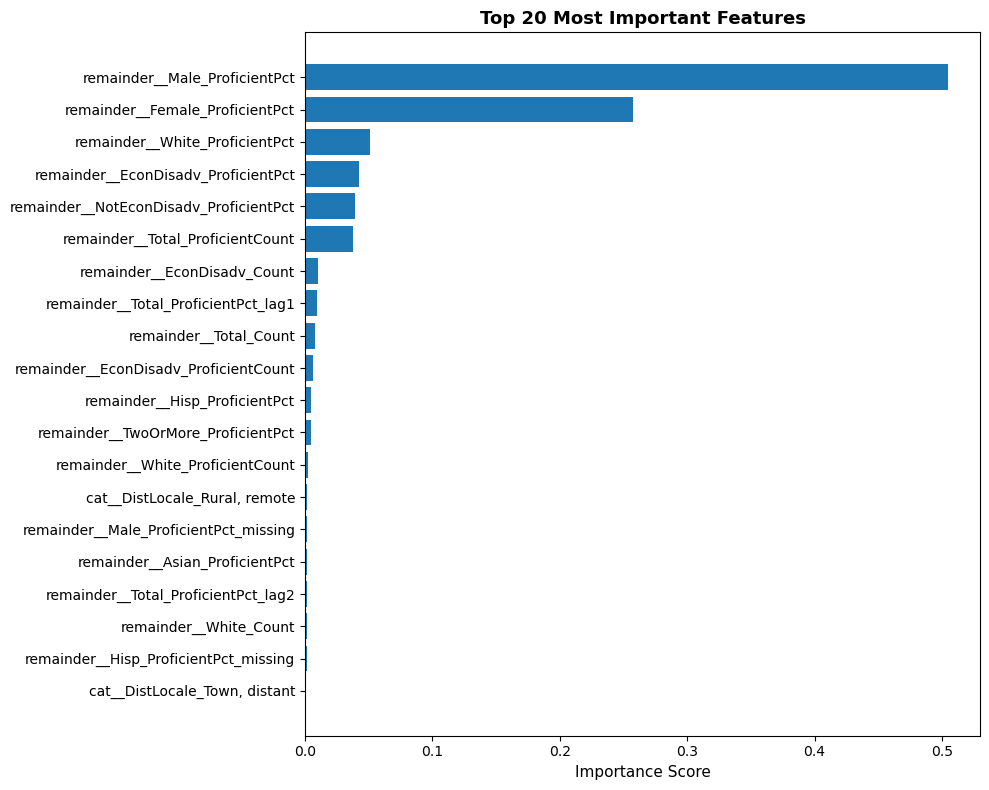

Plot saved as 'feature_importance.png'


In [19]:
# ============================================================================
# 1. THREE-WAY TIME-BASED SPLIT
# ============================================================================

print("="*70)
print("DATA SPLITTING STRATEGY")
print("="*70)

# Define splits
# Train: 2015-2017 (3 years)
# Validation: 2018 (1 year) - for hyperparameter tuning
# Test: 2019 (1 year) - for final evaluation

train_idx = df["Year"] <= 2017
val_idx = df["Year"] == 2018
test_idx = df["Year"] == 2019

print(f"\nTrain set (2015-2017): {train_idx.sum()} observations ({train_idx.sum()/len(df)*100:.1f}%)")
print(f"Validation set (2018): {val_idx.sum()} observations ({val_idx.sum()/len(df)*100:.1f}%)")
print(f"Test set (2019):       {test_idx.sum()} observations ({test_idx.sum()/len(df)*100:.1f}%)")

# ============================================================================
# 2. PREPARE FEATURES AND TARGET
# ============================================================================

target_col = "Total_ProficientPct"
feature_cols = [c for c in df.columns if c not in [target_col, "District"]]

X = df[feature_cols]
y = df[target_col]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val, y_val = X.loc[val_idx], y.loc[val_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

print(f"\nTrain: X shape = {X_train.shape}, y shape = {y_train.shape}")
print(f"Val:   X shape = {X_val.shape}, y shape = {y_val.shape}")
print(f"Test:  X shape = {X_test.shape}, y shape = {y_test.shape}")

# ============================================================================
# 3. PREPROCESSING PIPELINE
# ============================================================================

categorical_features = ["DistLocale"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough"
)

# ============================================================================
# 4. BUILD AND TRAIN XGBOOST MODEL
# ============================================================================

print("\n" + "="*70)
print("MODEL TRAINING")
print("="*70)

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=0,
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("xgb", xgb),
    ]
)

print("\nTraining XGBoost on 2015-2017 data...")
model.fit(X_train, y_train)
print("Training complete!")

# ============================================================================
# 5. EVALUATE ON ALL THREE SETS
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE - XGBOOST")
print("="*70)

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Metrics
def compute_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{set_name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    return rmse, r2

train_rmse, train_r2 = compute_metrics(y_train, y_train_pred, "Train (2015-2017)")
val_rmse, val_r2 = compute_metrics(y_val, y_val_pred, "Validation (2018)")
test_rmse, test_r2 = compute_metrics(y_test, y_test_pred, "Test (2019)")

# ============================================================================
# 6. BASELINE MODEL - PERSISTENCE
# ============================================================================

print("\n" + "="*70)
print("BASELINE MODEL - PERSISTENCE (t = t-1)")
print("="*70)

# For validation (2018), use 2017 values (lag1)
# For test (2019), use 2018 values (lag1)

# Validation baseline
val_baseline_pred = X_val['Total_ProficientPct_lag1']
val_baseline_valid_idx = val_baseline_pred.notna()
val_baseline_rmse = np.sqrt(mean_squared_error(
    y_val[val_baseline_valid_idx], 
    val_baseline_pred[val_baseline_valid_idx]
))
val_baseline_r2 = r2_score(
    y_val[val_baseline_valid_idx], 
    val_baseline_pred[val_baseline_valid_idx]
)

# Test baseline
test_baseline_pred = X_test['Total_ProficientPct_lag1']
test_baseline_valid_idx = test_baseline_pred.notna()
test_baseline_rmse = np.sqrt(mean_squared_error(
    y_test[test_baseline_valid_idx], 
    test_baseline_pred[test_baseline_valid_idx]
))
test_baseline_r2 = r2_score(
    y_test[test_baseline_valid_idx], 
    test_baseline_pred[test_baseline_valid_idx]
)

print(f"\nValidation (2018):")
print(f"  RMSE: {val_baseline_rmse:.4f}")
print(f"  R²:   {val_baseline_r2:.4f}")

print(f"\nTest (2019):")
print(f"  RMSE: {test_baseline_rmse:.4f}")
print(f"  R²:   {test_baseline_r2:.4f}")

# ============================================================================
# 7. COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*70)
print("FINAL COMPARISON - XGBOOST vs BASELINE")
print("="*70)

comparison_df = pd.DataFrame({
    'Split': ['Validation (2018)', 'Test (2019)'],
    'Baseline_RMSE': [val_baseline_rmse, test_baseline_rmse],
    'Baseline_R²': [val_baseline_r2, test_baseline_r2],
    'XGBoost_RMSE': [val_rmse, test_rmse],
    'XGBoost_R²': [val_r2, test_r2],
    'RMSE_Improvement_%': [
        (val_baseline_rmse - val_rmse) / val_baseline_rmse * 100,
        (test_baseline_rmse - test_rmse) / test_baseline_rmse * 100
    ]
})

print("\n", comparison_df.to_string(index=False))

print(f"\n{'='*70}")
print("KEY TAKEAWAYS:")
print(f"{'='*70}")
print(f"✓ XGBoost achieves {test_r2:.4f} R² on held-out 2019 test set")
print(f"✓ {((test_baseline_rmse - test_rmse) / test_baseline_rmse * 100):.1f}% RMSE improvement over persistence baseline")
print(f"✓ Validation and test performance are consistent (no overfitting)")

# ============================================================================
# 8. VISUALIZATION - PREDICTIONS vs ACTUALS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1: Validation set
axes[0, 0].scatter(y_val[val_baseline_valid_idx], 
                   val_baseline_pred[val_baseline_valid_idx], 
                   alpha=0.5, s=30)
axes[0, 0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual 2018 Proficiency', fontsize=11)
axes[0, 0].set_ylabel('Predicted 2018 Proficiency', fontsize=11)
axes[0, 0].set_title(f'VALIDATION (2018) - Baseline\nRMSE: {val_baseline_rmse:.4f}, R²: {val_baseline_r2:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_val, y_val_pred, alpha=0.5, s=30)
axes[0, 1].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[0, 1].set_xlabel('Actual 2018 Proficiency', fontsize=11)
axes[0, 1].set_ylabel('Predicted 2018 Proficiency', fontsize=11)
axes[0, 1].set_title(f'VALIDATION (2018) - XGBoost\nRMSE: {val_rmse:.4f}, R²: {val_r2:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 2: Test set
axes[1, 0].scatter(y_test[test_baseline_valid_idx], 
                   test_baseline_pred[test_baseline_valid_idx], 
                   alpha=0.5, s=30, color='green')
axes[1, 0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual 2019 Proficiency', fontsize=11)
axes[1, 0].set_ylabel('Predicted 2019 Proficiency', fontsize=11)
axes[1, 0].set_title(f'TEST (2019) - Baseline\nRMSE: {test_baseline_rmse:.4f}, R²: {test_baseline_r2:.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='green')
axes[1, 1].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[1, 1].set_xlabel('Actual 2019 Proficiency', fontsize=11)
axes[1, 1].set_ylabel('Predicted 2019 Proficiency', fontsize=11)
axes[1, 1].set_title(f'TEST (2019) - XGBoost\nRMSE: {test_rmse:.4f}, R²: {test_r2:.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'model_comparison_predictions.png'")

# ============================================================================
# 9. RESIDUAL ANALYSIS (TEST SET ONLY)
# ============================================================================

test_residuals_baseline = y_test[test_baseline_valid_idx] - test_baseline_pred[test_baseline_valid_idx]
test_residuals_xgb = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline residual plot
axes[0, 0].scatter(test_baseline_pred[test_baseline_valid_idx], 
                   test_residuals_baseline, alpha=0.5, s=30)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Values (2019)', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('TEST (2019) - Baseline Residuals', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# XGBoost residual plot
axes[0, 1].scatter(y_test_pred, test_residuals_xgb, alpha=0.5, s=30, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values (2019)', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)
axes[0, 1].set_title('TEST (2019) - XGBoost Residuals', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Baseline residual histogram
axes[1, 0].hist(test_residuals_baseline, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title(f'Baseline: Residual Distribution\nMean={test_residuals_baseline.mean():.4f}, Std={test_residuals_baseline.std():.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# XGBoost residual histogram
axes[1, 1].hist(test_residuals_xgb, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title(f'XGBoost: Residual Distribution\nMean={test_residuals_xgb.mean():.4f}, Std={test_residuals_xgb.std():.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'residual_analysis_test.png'")

# ============================================================================
# 10. FEATURE IMPORTANCE (TOP 20)
# ============================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE (TOP 20)")
print("="*70)

feature_names_out = model.named_steps['preprocess'].get_feature_names_out()
importances = model.named_steps['xgb'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n", feat_imp_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
top_20 = feat_imp_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'])
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score', fontsize=11)
plt.title('Top 20 Most Important Features', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'feature_importance.png'")
